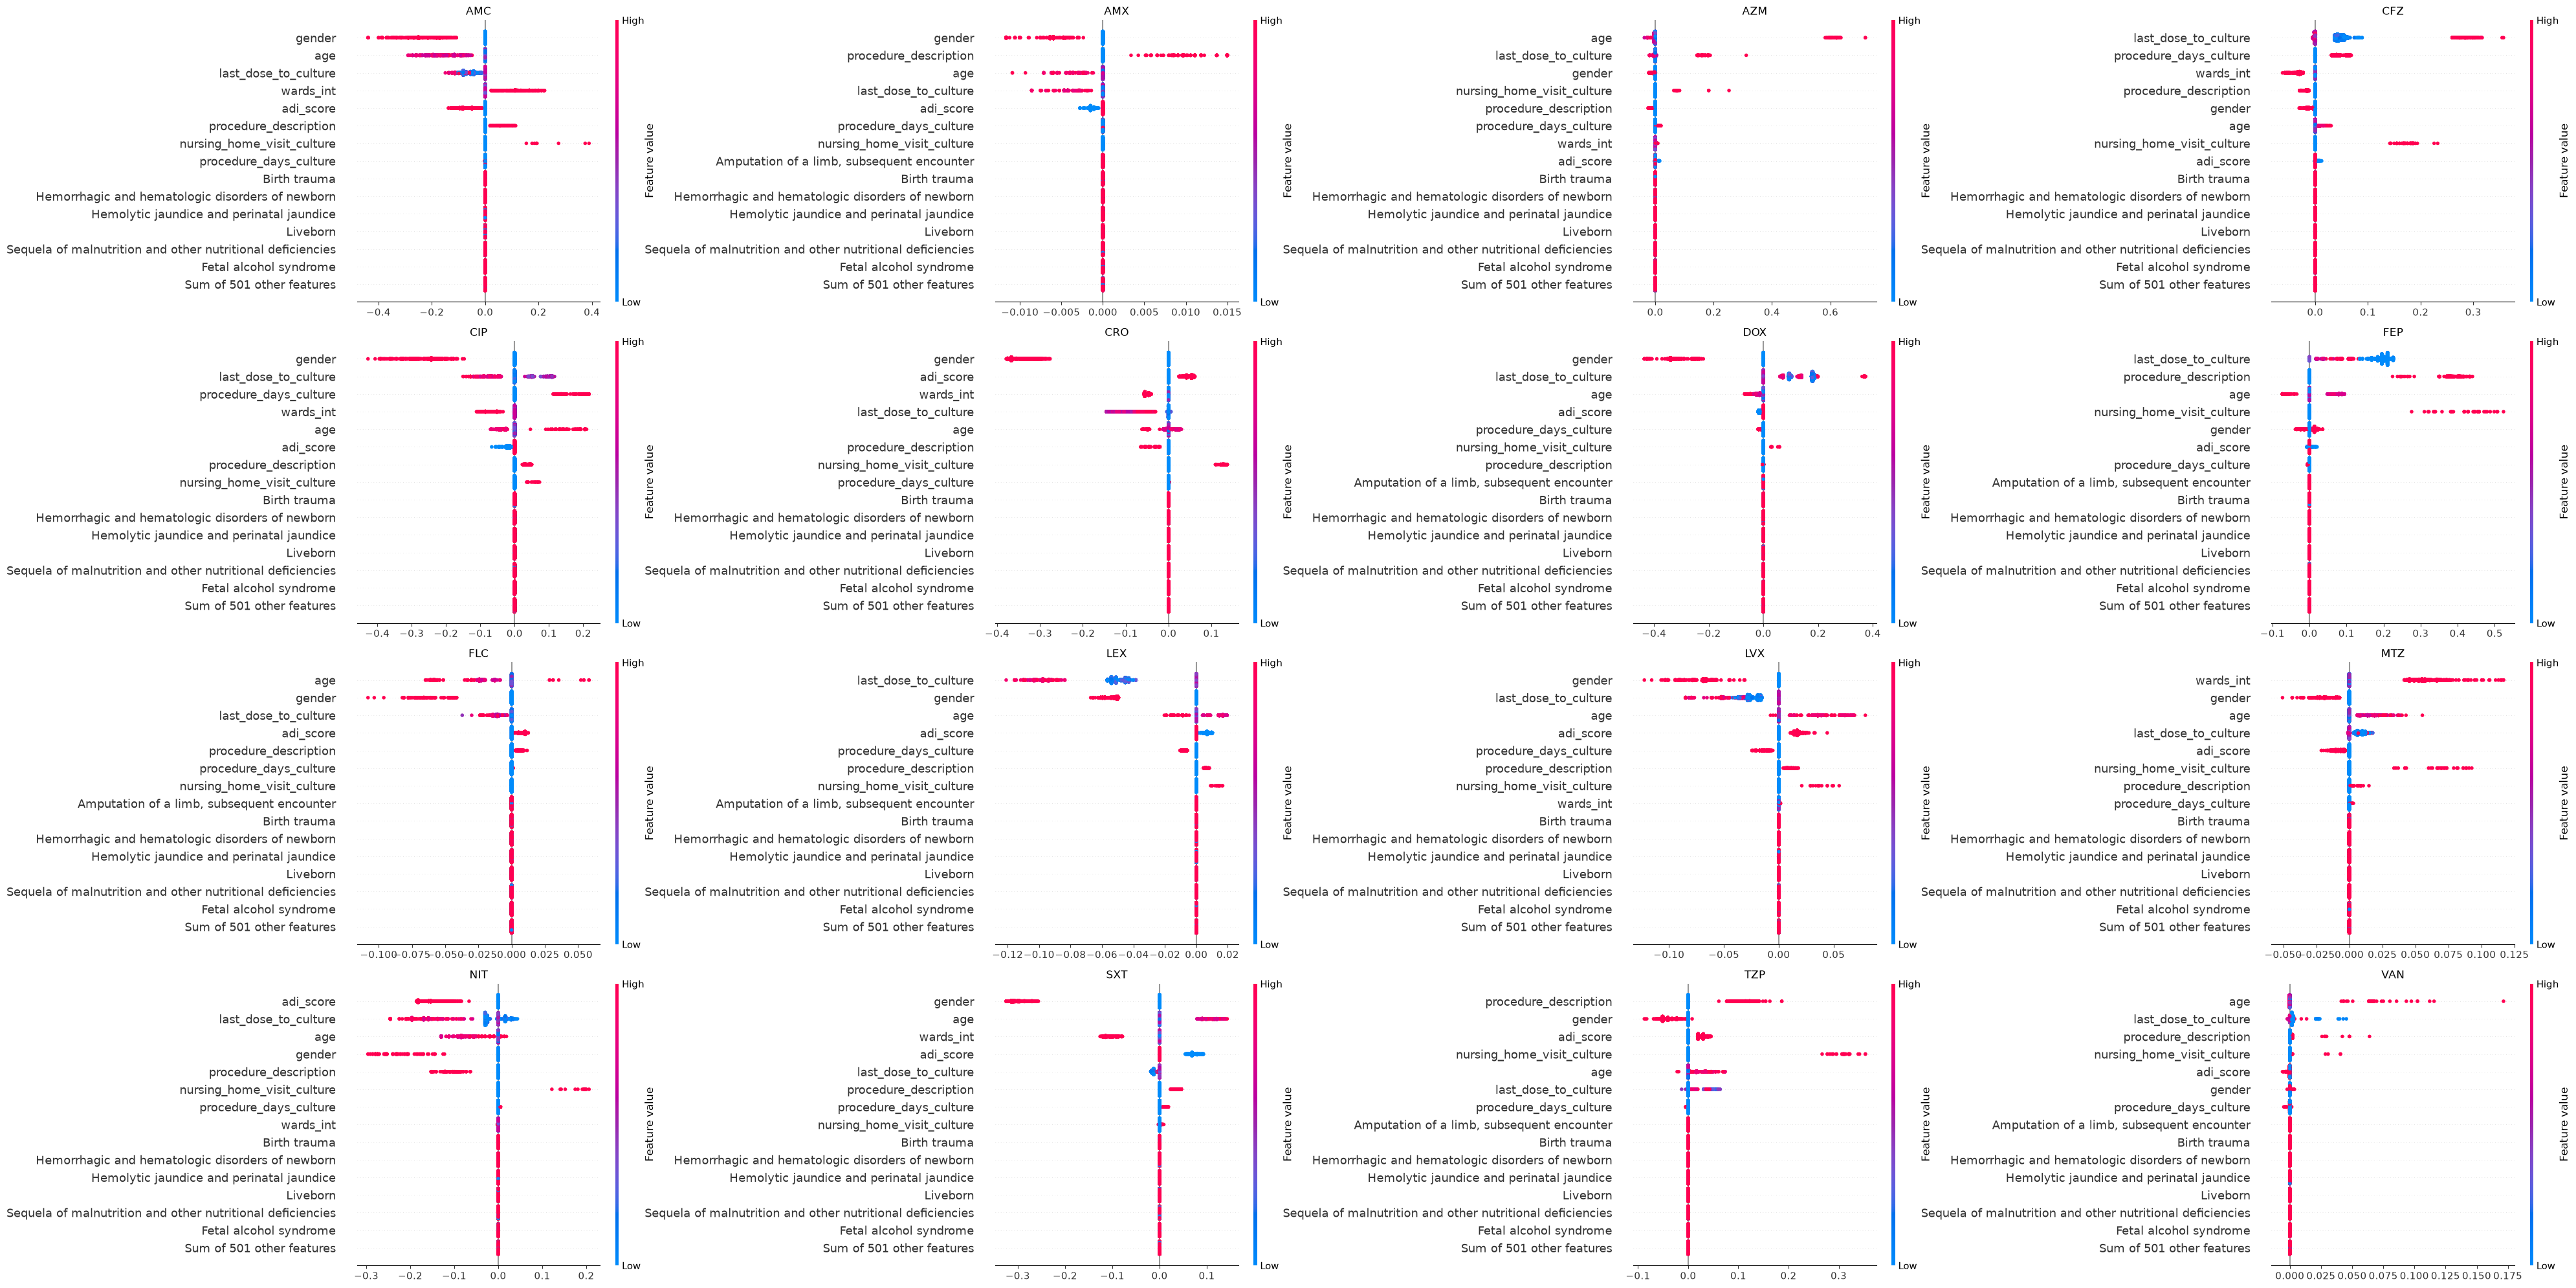

In [21]:
import shap
import pickle
import pandas as pd
import matplotlib.pyplot as plt

drugs_list = ["AMC", "AMX", "AZM", "CFZ", "CIP", "CRO", "DOX", "FEP", "FLC", "LEX", "LVX", "MTZ", "NIT", "SXT", "TZP", "VAN"]
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(40, 20))
axes_flat = axes.flatten()

for i in range(len(drugs_list)):
    DRUG = drugs_list[i]
    with open(f"CShapley/{DRUG}.sav", "rb") as file:
        shapley = pickle.load(file)
    if "_reduced" in DRUG:
        df = pd.read_csv(f"dataset/by_antibiotic_12comorbdims/{DRUG.split("_")[0]}.csv")
        features = list(df.drop(columns=["anon_id","order_time_jittered_utc_shifted","resistant","Unnamed: 0"]).columns)
    else:
        df = pd.read_csv(f"dataset/by_antibiotic/{DRUG}.csv")
        features = list(df.drop(columns=["anon_id","order_time_jittered_utc_shifted","resistant","Unnamed: 0",'Unnamed: 0.3', 'Unnamed: 0.2', 'Unnamed: 0.1']).columns)
    shapley.feature_names = features
    shap.plots.beeswarm(shapley[:,:,1], max_display=15, ax=axes_flat[i], show=False, plot_size=None)
    axes_flat[i].set_xlabel('')
    axes_flat[i].set_title(DRUG)


plt.tight_layout()
plt.show()